# 07. 探索: Searching

データ構造の中から、特定の要素を見つけ出す操作を「探索」と呼ぶ。
探索にも単純なものから効率化したものまで様々なアルゴリズムが存在する。

Searching Algorithms are methods used to locate specific elements within data structures. 
These algorithms can range from simple linear searches to more complex and efficient methods like binary search.

----
- [線形探索: Linear Search](#線形探索)
- [二分探索: Binary Search](#二分探索)
- [二分探索木: Binary Search Tree](#二分探索木)

In [15]:
import random

## 線形探索: Linear Search

線形探索は、データ構造の要素を一つずつ順番に調べていく最も基本的な探索方法である。
要素数$n$のリストに、データがでたらめに配置されているとする。
あらかじめ探索対象が入っている位置はわからないため、平均で$n/2$回の比較が必要になる。
最後まで見つからない場合には、$n$回の比較が必要になる。
いずれにしても、線形探索の時間計算量は$O(n)$である。

----
The linear search algorithm is the most basic method of searching, where each element in a data structure is examined one by one in order.
Assuming a list of $n$ elements with randomly arranged data, on average, it requires $n/2$ comparisons to find the target element.
If the element is not found after checking all elements, it requires $n$ comparisons.
In any case, the time complexity of linear search is $O(n)$.


In [16]:
def linear_search(arr:list, target) ->tuple[bool, int]:
    for i in range(len(arr)):
        if arr[i] == target:
            return (True, i)
    return (False, -1)

In [17]:
n = 20
max_value = 50
data = [random.randint(0, max_value) for _ in range(n)]
target = random.randint(0, max_value)
b,k = linear_search(data, target)
if b:
    print(f"Found {target} at index {k} in data.")
else:
    print(f"{target} not found in data.")


Found 31 at index 15 in data.


## 二分探索: Binary Search

仮に、データが昇順に整列されているとする。
この場合、探索対象の値が、リストのある位置よりも左側にあるのか右側にあるのかを比較によって判定できる。
- リストの長さを$n$とし、探索対象の値を$v$とする。
- リストの中央の要素$d$と$v$を比較する。
  - $v < d$ならば、探索対象はリストの左半分にある。
  - $v > d$ならば、探索対象はリストの右半分にある。
  - $v = d$ならば、探索成功で終了する。
- 探索対象が存在する側の半分のリストに対して、同様の操作を繰り返す。
このように、探索のたびに探索範囲が半分になるため、二分探索の時間計算量は$O(\log_2 n)$である。

----
Assuming the data is sorted in ascending order, the binary search algorithm can determine whether the target value is located to the left or right of a given position in the list through comparisons.
- Let the length of the list be $n$ and the target value be $v$.
- Compare $v$ with the middle element $d$ of the list.
  - If $v < d$, the target is in the left half of the list.
  - If $v > d$, the target is in the right half of the list.
  - If $v = d$, the search is successful and ends.
- Repeat the same process on the half of the list where the target exists.
Since the search range is halved with each comparison, the time complexity of binary search is $O(\log_2 n)$.

In [18]:
def binary_search(arr:list, target) ->tuple[bool, int]:
    left = 0
    right = len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return (True, mid)
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return (False, -1)

二分探索は、再帰的に実装することもできる。
- リストの左端を`left`、右端を`right`とする。
- `left`が`right`より大きくなった場合、探索対象は存在しないため、探索失敗で終了する。
- リストの中央の要素を`mid`とする。
- `mid`の要素と探索対象を比較する。
  - 等しい場合、探索成功で終了する。
  - 探索対象が`mid`の要素より小さい場合、探索対象はリストの左半分にある
    - `left`から`mid - 1`の範囲で、再帰的に二分探索を行う。
  - 探索対象が`mid`の要素より大きい場合、探索対象はリストの右半分にある
    - `mid + 1`から`right`の範囲で、再帰的に二分探索を行う。

----
Binary search can also be implemented recursively.
- Let `left` be the leftmost index and `right` be the rightmost index of the list.
- If `left` is greater than `right`, the target does not exist, and the search fails.
- Let `mid` be the index of the middle element of the list.
- Compare the element at `mid` with the target.
  - If they are equal, the search is successful and ends.
  - If the target is less than the element at `mid`, the target is in the left half of the list
    - Perform a recursive binary search on the range from `left` to `mid - 1`.
  - If the target is greater than the element at `mid`, the target is in the right half of the list
    - Perform a recursive binary search on the range from `mid + 1` to `right`.

In [ ]:
def binary_search_recursive(arr:list, target, left, right) ->tuple[bool, int]:
    if left > right:
        return (False, -1)  # Not found
    mid = (left + right) // 2
    if arr[mid] == target:
        return (True, mid)  # Found
    elif arr[mid] > target:
        # Search in the left half
        return binary_search_recursive(arr, target, left, mid - 1)
    else:
        # Search in the right half
        return binary_search_recursive(arr, target, mid + 1, right)

In [19]:
n = 20
max_value = 50
data = [random.randint(0, max_value) for _ in range(n)]
data.sort()
target = random.randint(0, max_value)
b,k = linear_search(data, target)
if b:
    print(f"Found {target} at index {k} in data.")
else:
    print(f"{target} not found in data.")

34 not found in data.


### 課題: Exercise
再帰的な二分探索を実行し、動作を確認しなさい。

Execute the recursive binary search and verify its functionality.

## 二分探索木: Binary Search Tree
二分探索に適したデータ構造として、二分探索木がある。
二分探索木は、各ノードが最大で2つの子ノードを持つ木構造であり、以下の性質を持つ。
- 各ノードの左部分木には、そのノードの値よりも小さいはたは等しい値が含まれる。
- 各ノードの右部分木には、そのノードの値よりも大きい値が含まれる。
この性質により、二分探索木を用いることで、効率的な探索が可能となる。

----
A binary search tree (BST) is a data structure that is well-suited for binary search.
A BST is a tree structure where each node has at most two child nodes and possesses the following properties:
- The left subtree of each node contains values that are less than or equal to the value of that node.
- The right subtree of each node contains values that are greater than the value of that node.
These properties allow for efficient searching when using a binary search tree.

In [ ]:
class Node: # 二分探索木のノード: Node of a binary search tree
    def __init__(self, label,key):
        self.left: Node|None = None
        self.right: Node|None = None
        self.val = key
        self.label = label

class BinarySearchTree:
    """
    二分探索木: Binary Search Tree
    """
    def __init__(self):
        self.root: Node|None = None

    def insert(self, label, key):
        """
        keyを持つ新しいノードを挿入
        Insert a new node with the given key
        """
        if self.root is None: 
            # 木が空の場合、新しいノードが根になる
            # If the tree is empty, the new node becomes the root
            self.root = Node(label, key)
        else:
            self._insert_rec(self.root, label, key)

    def _insert_rec(self, node: Node, label, key):
        # 新しいノードを再帰的に挿入するためのプライベートメソッド
        # Private method to insert a new node recursively
        if key <= node.val:
            if node.left is None:
                node.left = Node(label, key)
            else:
                self._insert_rec(node.left, label, key)
        else:
            if node.right is None:
                node.right = Node(label, key)
            else:
                self._insert_rec(node.right, label, key)

    def search(self, key) -> bool:
        """
        keyを持つノードを探索
        Search for a node with the given key
        """
        if self.root is None:
            return False
        return self._search_rec(self.root, key)

    def _search_rec(self, root: Node, key) -> bool:
        # keyを持つノードを再帰的に探索するためのプライベートメソッド
        # Private method to search for a node with the given key recursively
        if root is None:
            return False
        if root.val == key:
            return True
        elif key < root.val:
            if root.left is None:
                return False
            return self._search_rec(root.left, key)
        else:
            if root.right is None:
                return False
            return self._search_rec(root.right, key)


In [ ]:
n = 20
max_value = 50
data = [random.randint(0, max_value) for _ in range(n)]
bst = BinarySearchTree()
for i, num in enumerate(data):
    bst.insert(f"{i}", num)
target = random.randint(0, max_value)
b = bst.search(target)
if b:
    print(f"Found {target} in BST.")
else:
    print(f"{target} not found in BST.")

[37, 43, 23, 46, 5, 33, 17, 43, 42, 48, 7, 8, 42, 6, 29, 35, 41, 43, 35, 27]
Found 43 in BST.


### 二分探索木の可視化: Visualizing Binary Search Trees

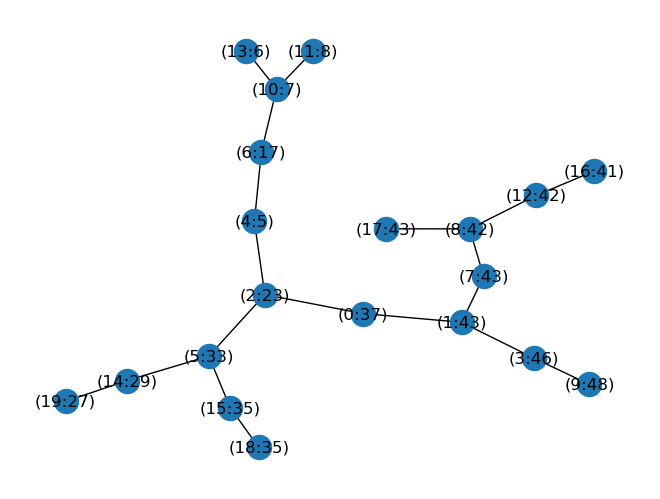

In [29]:
import networkx as nx
def visualize_bst(bst: BinarySearchTree) -> nx.Graph:
    """
    二分探索木を可視化するための関数
    Function to visualize a binary search tree
    """
    G = nx.Graph()
    def add_edges(node: Node|None):
        if node is not None:
            node_label = f"({node.label}:{node.val})"
            if node.left is not None:
                left_label = f"({node.left.label}:{node.left.val})"
                G.add_edge(node_label, left_label)
                add_edges(node.left)
            if node.right is not None:
                right_label = f"({node.right.label}:{node.right.val})"
                G.add_edge(node_label, right_label)
                add_edges(node.right)
    add_edges(bst.root)
    return G

g = visualize_bst(bst)
pos = nx.spring_layout(g) # ノードの位置を決定するためのレイアウト
nx.draw(g, pos, with_labels=True)
